In [65]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 自动导航文件夹 week2_sequence_alignment
path = os.getcwd()
while path != os.path.dirname(path):
    if "week2_sequence_alignment" in os.listdir(path):
        os.chdir(path)
        break
    path = os.path.dirname(path)

print("当前工作目录已精准锁定在仓库根目录:", os.getcwd())

当前工作目录已精准锁定在仓库根目录: /mnt/e/Linux/bioinformatics/igem/igem-model-training-2027


In [66]:
match_score = 1
mismatch_score = -1
gap_penalty = -2

def init_nw_matrix(seq1, seq2, gap):
    M = len(seq1)
    N = len(seq2)
    
    # 创建一个全 0 矩阵
    # 行代表 seq1 的碱基，列代表 seq2 的碱基
    score_matrix = np.zeros((M + 1, N + 1))
    
    # 2. 初始化第一列
    for i in range(M + 1):
        score_matrix[i][0] = i * gap
        
    # 3. 初始化第一行
    for j in range(N + 1):
        score_matrix[0][j] = j * gap
        
    return score_matrix

# 测试一下 GATTACA 和 GCATGCU 的初始化
test_matrix = init_nw_matrix("GATTACA", "GCATGCU", gap_penalty)
print("初始化后的 NW 矩阵：\n", test_matrix)

初始化后的 NW 矩阵：
 [[  0.  -2.  -4.  -6.  -8. -10. -12. -14.]
 [ -2.   0.   0.   0.   0.   0.   0.   0.]
 [ -4.   0.   0.   0.   0.   0.   0.   0.]
 [ -6.   0.   0.   0.   0.   0.   0.   0.]
 [ -8.   0.   0.   0.   0.   0.   0.   0.]
 [-10.   0.   0.   0.   0.   0.   0.   0.]
 [-12.   0.   0.   0.   0.   0.   0.   0.]
 [-14.   0.   0.   0.   0.   0.   0.   0.]]


In [67]:
def needleman_wunsch(seq1, seq2, match=1, mismatch=-1, gap=-2):
    m, n = len(seq1), len(seq2)
    
    # 初始化规则
    score_matrix = np.zeros((m + 1, n + 1), dtype=int)
    for i in range(m + 1):
        score_matrix[i][0] = i * gap
    for j in range(n + 1):
        score_matrix[0][j] = j * gap
        
    # 填充 DP 矩阵
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            # 判断匹配还是错配
            if seq1[i - 1] == seq2[j - 1]:
                s = match
            else:
                s = mismatch
                
            # 计算三个方向的候选得分
            diag_score = score_matrix[i - 1][j - 1] + s
            up_score = score_matrix[i - 1][j] + gap
            left_score = score_matrix[i][j - 1] + gap
            
            # 取最大值填充进当前格子
            score_matrix[i][j] = max(diag_score, up_score, left_score)
            
    # 最终比对得分就是矩阵右下角的值
    final_score = int(score_matrix[m][n])
    
    # Traceback找最优路径
    aligned_seq1 = ""
    aligned_seq2 = ""
    i, j = m, n
    
    #用于记录回溯经过的坐标点
    path_coords = [(i, j)]
    
    # 从右下角一直回溯到左上角 (0, 0)
    while i > 0 or j > 0:
        # 当前格子和碱基的匹配/错配得分
        if i > 0 and j > 0:
            s = match if seq1[i - 1] == seq2[j - 1] else mismatch
        else:
            s = mismatch
            
        # 路径 A：如果是从对角线退回来的（优先对角线对齐）
        if i > 0 and j > 0 and score_matrix[i][j] == score_matrix[i - 1][j - 1] + s:
            aligned_seq1 += seq1[i - 1]
            aligned_seq2 += seq2[j - 1]
            i -= 1
            j -= 1
            
        # 路径 B：如果是从上方退回来的（在 seq2 中插入 gap）
        elif i > 0 and score_matrix[i][j] == score_matrix[i - 1][j] + gap:
            aligned_seq1 += seq1[i - 1]
            aligned_seq2 += "-"
            i -= 1
            
        # 路径 C：如果是从左方退回来的（在 seq1 中插入 gap）
        elif j > 0 and score_matrix[i][j] == score_matrix[i][j - 1] + gap:
            aligned_seq1 += "-"
            aligned_seq2 += seq2[j - 1]
            j -= 1
            
        #每次移动，记录新的坐标
        path_coords.append((i, j))
        
    # 因为是倒着回溯的，所以需要把字符串反转过来
    aligned_seq1 = aligned_seq1[::-1]
    aligned_seq2 = aligned_seq2[::-1]
    
    return score_matrix, aligned_seq1, aligned_seq2, final_score, path_coords

In [68]:
#测试
seq1 = "GATTACA"
seq2 = "GCATGCU"

mat, al1, al2, score, path_coords = needleman_wunsch(seq1, seq2, match=1, mismatch=-1, gap=-2)

print("【比对最终得分】:", score)
print("【比对序列 1】:", al1)
print("【比2序列 2】:", al2)
print("【Traceback 路径坐标】:", path_coords)  # 我们可以顺便把坐标也打印出来看看
print("\n【最终填充完的完整 DP 矩阵】：\n", mat)

【比对最终得分】: -1
【比对序列 1】: GATTACA
【比2序列 2】: GCATGCU
【Traceback 路径坐标】: [(7, 7), (6, 6), (5, 5), (4, 4), (3, 3), (2, 2), (1, 1), (0, 0)]

【最终填充完的完整 DP 矩阵】：
 [[  0  -2  -4  -6  -8 -10 -12 -14]
 [ -2   1  -1  -3  -5  -7  -9 -11]
 [ -4  -1   0   0  -2  -4  -6  -8]
 [ -6  -3  -2  -1   1  -1  -3  -5]
 [ -8  -5  -4  -3   0   0  -2  -4]
 [-10  -7  -6  -3  -2  -1  -1  -3]
 [-12  -9  -6  -5  -4  -3   0  -2]
 [-14 -11  -8  -5  -6  -5  -2  -1]]


In [69]:
def smith_waterman(seq1, seq2, match=1, mismatch=-1, gap=-2):
    m, n = len(seq1), len(seq2)
    
    # 初始化得分矩阵为全 0
    score_matrix = np.zeros((m + 1, n + 1), dtype=int)
    
    # 记录矩阵中的最大值及其坐标（作为回溯起点）
    best_local_score = 0
    best_end_position = (0, 0)
    
    # 填充 DP 矩阵
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if seq1[i - 1] == seq2[j - 1]:
                s = match
            else:
                s = mismatch
                
            diag_score = score_matrix[i - 1][j - 1] + s
            up_score = score_matrix[i - 1][j] + gap
            left_score = score_matrix[i][j - 1] + gap
            
            # 多了一个 0，保证不出现负分
            score_matrix[i][j] = max(0, diag_score, up_score, left_score)
            
            # 实时记录最大得分和位置
            if score_matrix[i][j] > best_local_score:
                best_local_score = score_matrix[i][j]
                best_end_position = (i, j)
                
    # 反向回溯
    aligned_seq1 = ""
    aligned_seq2 = ""
    i, j = best_end_position

    #从最高得分位置开始记录路径
    path_coords = [(i, j)]
    
    while i > 0 or j > 0:
        # 一旦回到值为 0 的格子，立即停止回溯
        if score_matrix[i][j] == 0:
            break
            
        if i > 0 and j > 0:
            s = match if seq1[i - 1] == seq2[j - 1] else mismatch
        else:
            s = mismatch
            
        # 回溯判定：看当前分是从哪个方向递推过来的
        if i > 0 and j > 0 and score_matrix[i][j] == score_matrix[i - 1][j - 1] + s:
            aligned_seq1 += seq1[i - 1]
            aligned_seq2 += seq2[j - 1]
            i -= 1
            j -= 1
        elif i > 0 and score_matrix[i][j] == score_matrix[i - 1][j] + gap:
            aligned_seq1 += seq1[i - 1]
            aligned_seq2 += "-"
            i -= 1
        elif j > 0 and score_matrix[i][j] == score_matrix[i][j - 1] + gap:
            aligned_seq1 += "-"
            aligned_seq2 += seq2[j - 1]
            j -= 1

        path_coords.append((i, j))
        
    # 反转序列
    aligned_seq1 = aligned_seq1[::-1]
    aligned_seq2 = aligned_seq2[::-1]
    
    return score_matrix, aligned_seq1, aligned_seq2, best_local_score, best_end_position, path_coords

In [70]:
# 运行测试
sw_mat, sw_al1, sw_al2, sw_score, sw_pos, sw_path = smith_waterman(seq1, seq2, match=1, mismatch=-1, gap=-2)

print("【SW 局部比对最高得分】:", sw_score)
print("【SW 最佳回溯起点坐标】:", sw_pos)
print("【SW 局部比对序列 1】:", sw_al1)
print("【SW 局部比对序列 2】:", sw_al2)
print("【SW Traceback 路径坐标】:", sw_path)
print("\n【最终填充完的 SW 矩阵】：\n", sw_mat)

【SW 局部比对最高得分】: 2
【SW 最佳回溯起点坐标】: (3, 4)
【SW 局部比对序列 1】: AT
【SW 局部比对序列 2】: AT
【SW Traceback 路径坐标】: [(3, 4), (2, 3), (1, 2)]

【最终填充完的 SW 矩阵】：
 [[0 0 0 0 0 0 0 0]
 [0 1 0 0 0 1 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 2 0 0 0]
 [0 0 0 0 1 1 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 1 0 0 0 1 0]
 [0 0 0 2 0 0 0 0]]


In [71]:
import os
import pandas as pd

# =====================================================================
# 使用相对路径进行路径配置（以仓库根目录为准）
# =====================================================================
YOUR_NAME = "paddypasteur"  # 个人目录名

DATA_PATH = "week2_sequence_alignment/data/demo_pairs.csv"
GLOBAL_OUT_PATH = f"submissions/{YOUR_NAME}/week2/results/week2_global_alignment_results.csv"
LOCAL_OUT_PATH = f"submissions/{YOUR_NAME}/week2/results/week2_local_alignment_results.csv"

# 读取输入数据
df_pairs = pd.read_csv(DATA_PATH)

# =====================================================================
#  1：运行 NW 全局比对，输出指定格式的结果表
# =====================================================================
global_records = []
for _, row in df_pairs.iterrows():
    p_id = row['pair_id']
    s1 = row['seq1']
    s2 = row['seq2']
    
    # 运行写好的 NW 算法，使用默认打分参数
    _, al1, al2, score, _ = needleman_wunsch(s1, s2, match=1, mismatch=-1, gap=-2)
    
    global_records.append({
        "pair_id": p_id,
        "algorithm": "NW",
        "match": 1,
        "mismatch": -1,
        "gap": -2,
        "score": score,
        "aligned_seq1": al1,
        "aligned_seq2": al2
    })

df_global_results = pd.DataFrame(global_records)
# 按照列顺序排列并保存
col_order = ["pair_id", "algorithm", "match", "mismatch", "gap", "score", "aligned_seq1", "aligned_seq2"]
df_global_results = df_global_results[col_order]
df_global_results.to_csv(GLOBAL_OUT_PATH, index=False)

print("NW完成，全局比对结果已保存至：\n", GLOBAL_OUT_PATH)


# =====================================================================
#  2：运行 SW 局部比对，输出指定格式的结果表
# =====================================================================
local_records = []
for _, row in df_pairs.iterrows():
    p_id = row['pair_id']
    s1 = row['seq1']
    s2 = row['seq2']
    
    # 运行 SW 算法，使用默认打分参数
    _, al1, al2, score, _, _ = smith_waterman(s1, s2, match=1, mismatch=-1, gap=-2)
    
    local_records.append({
        "pair_id": p_id,
        "algorithm": "SW",
        "match": 1,
        "mismatch": -1,
        "gap": -2,
        "score": score,
        "aligned_seq1": al1,
        "aligned_seq2": al2
    })

df_local_results = pd.DataFrame(local_records)
df_local_results = df_local_results[col_order]  # 保持列名与任务 1 绝对一致
df_local_results.to_csv(LOCAL_OUT_PATH, index=False)

print("SW完成，局部比对结果已保存至：\n", LOCAL_OUT_PATH)

NW完成，全局比对结果已保存至：
 submissions/paddypasteur/week2/results/week2_global_alignment_results.csv
SW完成，局部比对结果已保存至：
 submissions/paddypasteur/week2/results/week2_local_alignment_results.csv


In [72]:
# =====================================================================
# 搬运组长骨架里的辅助统计函数
# =====================================================================
def alignment_summary(aligned_seq1: str, aligned_seq2: str) -> dict:
    if len(aligned_seq1) != len(aligned_seq2):
        raise ValueError("Aligned sequences must have the same length.")
        
    number_of_matches = sum(
        a == b and a != "-" and b != "-"
        for a, b in zip(aligned_seq1, aligned_seq2)
    )
    number_of_gaps = sum(
        a == "-" or b == "-"
        for a, b in zip(aligned_seq1, aligned_seq2)
    )
    return {
        "alignment_length": len(aligned_seq1),
        "number_of_matches": number_of_matches,
        "number_of_gaps": number_of_gaps
    }

# =====================================================================
# 参数敏感性分析配置
# =====================================================================
YOUR_NAME = "paddypasteur"
DATA_PATH = "week2_sequence_alignment/data/demo_pairs.csv"
SENS_OUT_PATH = f"submissions/{YOUR_NAME}/week2/results/week2_parameter_sensitivity.csv"

# 读取输入数据
df_pairs = pd.read_csv(DATA_PATH)

# 定义 4 组打分参数
param_groups = [
    {"set": "A", "match": 1, "mismatch": -1, "gap": -1},
    {"set": "B", "match": 1, "mismatch": -1, "gap": -2}, 
    {"set": "C", "match": 2, "mismatch": -1, "gap": -2},
    {"set": "D", "match": 2, "mismatch": -2, "gap": -3}
]

# 创建存放的列表
sensitivity_records = []

# =====================================================================
# 运行嵌套循环，扫完 32 种组合
# =====================================================================
for _, row in df_pairs.iterrows():
    p_id = row['pair_id']
    s1 = row['seq1']
    s2 = row['seq2']
    
    for g in param_groups:
        p_set = g["set"]
        m_sc = g["match"]
        mis_sc = g["mismatch"]
        gp_pen = g["gap"]
        
        # 运行全局比对
        _, al1_nw, al2_nw, score_nw, _ = needleman_wunsch(s1, s2, m_sc, mis_sc, gp_pen)
        summary_nw = alignment_summary(al1_nw, al2_nw)
        
        sensitivity_records.append({
            "pair_id": p_id,
            "algorithm": "NW",
            "param_set": p_set,
            "match": m_sc,
            "mismatch": mis_sc,
            "gap": gp_pen,
            "score": score_nw,
            "aligned_seq1": al1_nw,
            "aligned_seq2": al2_nw,
            "alignment_length": summary_nw["alignment_length"],
            "number_of_matches": summary_nw["number_of_matches"],
            "number_of_gaps": summary_nw["number_of_gaps"]
        })
        
        # 运行局部比对
        _, al1_sw, al2_sw, score_sw, _, _ = smith_waterman(s1, s2, m_sc, mis_sc, gp_pen)
        summary_sw = alignment_summary(al1_sw, al2_sw)
        
        sensitivity_records.append({
            "pair_id": p_id,
            "algorithm": "SW",
            "param_set": p_set,
            "match": m_sc,
            "mismatch": mis_sc,
            "gap": gp_pen,
            "score": score_sw,
            "aligned_seq1": al1_sw,
            "aligned_seq2": al2_sw,
            "alignment_length": summary_sw["alignment_length"],
            "number_of_matches": summary_sw["number_of_matches"],
            "number_of_gaps": summary_sw["number_of_gaps"]
        })

# =====================================================================
# 转换 DataFrame 并按照要求输出
# =====================================================================
df_sens = pd.DataFrame(sensitivity_records)

required_cols = [
    "pair_id", "algorithm", "param_set", "match", "mismatch", "gap", "score", 
    "aligned_seq1", "aligned_seq2", "alignment_length", "number_of_matches", "number_of_gaps"
]

df_sens = df_sens[required_cols]
df_sens.to_csv(SENS_OUT_PATH, index=False)

print("参数敏感性分析结果已经保存至：\n", SENS_OUT_PATH)

参数敏感性分析结果已经保存至：
 submissions/paddypasteur/week2/results/week2_parameter_sensitivity.csv


两张热图已成功导出

--- 全局比对（NW）带路径图预览 ---


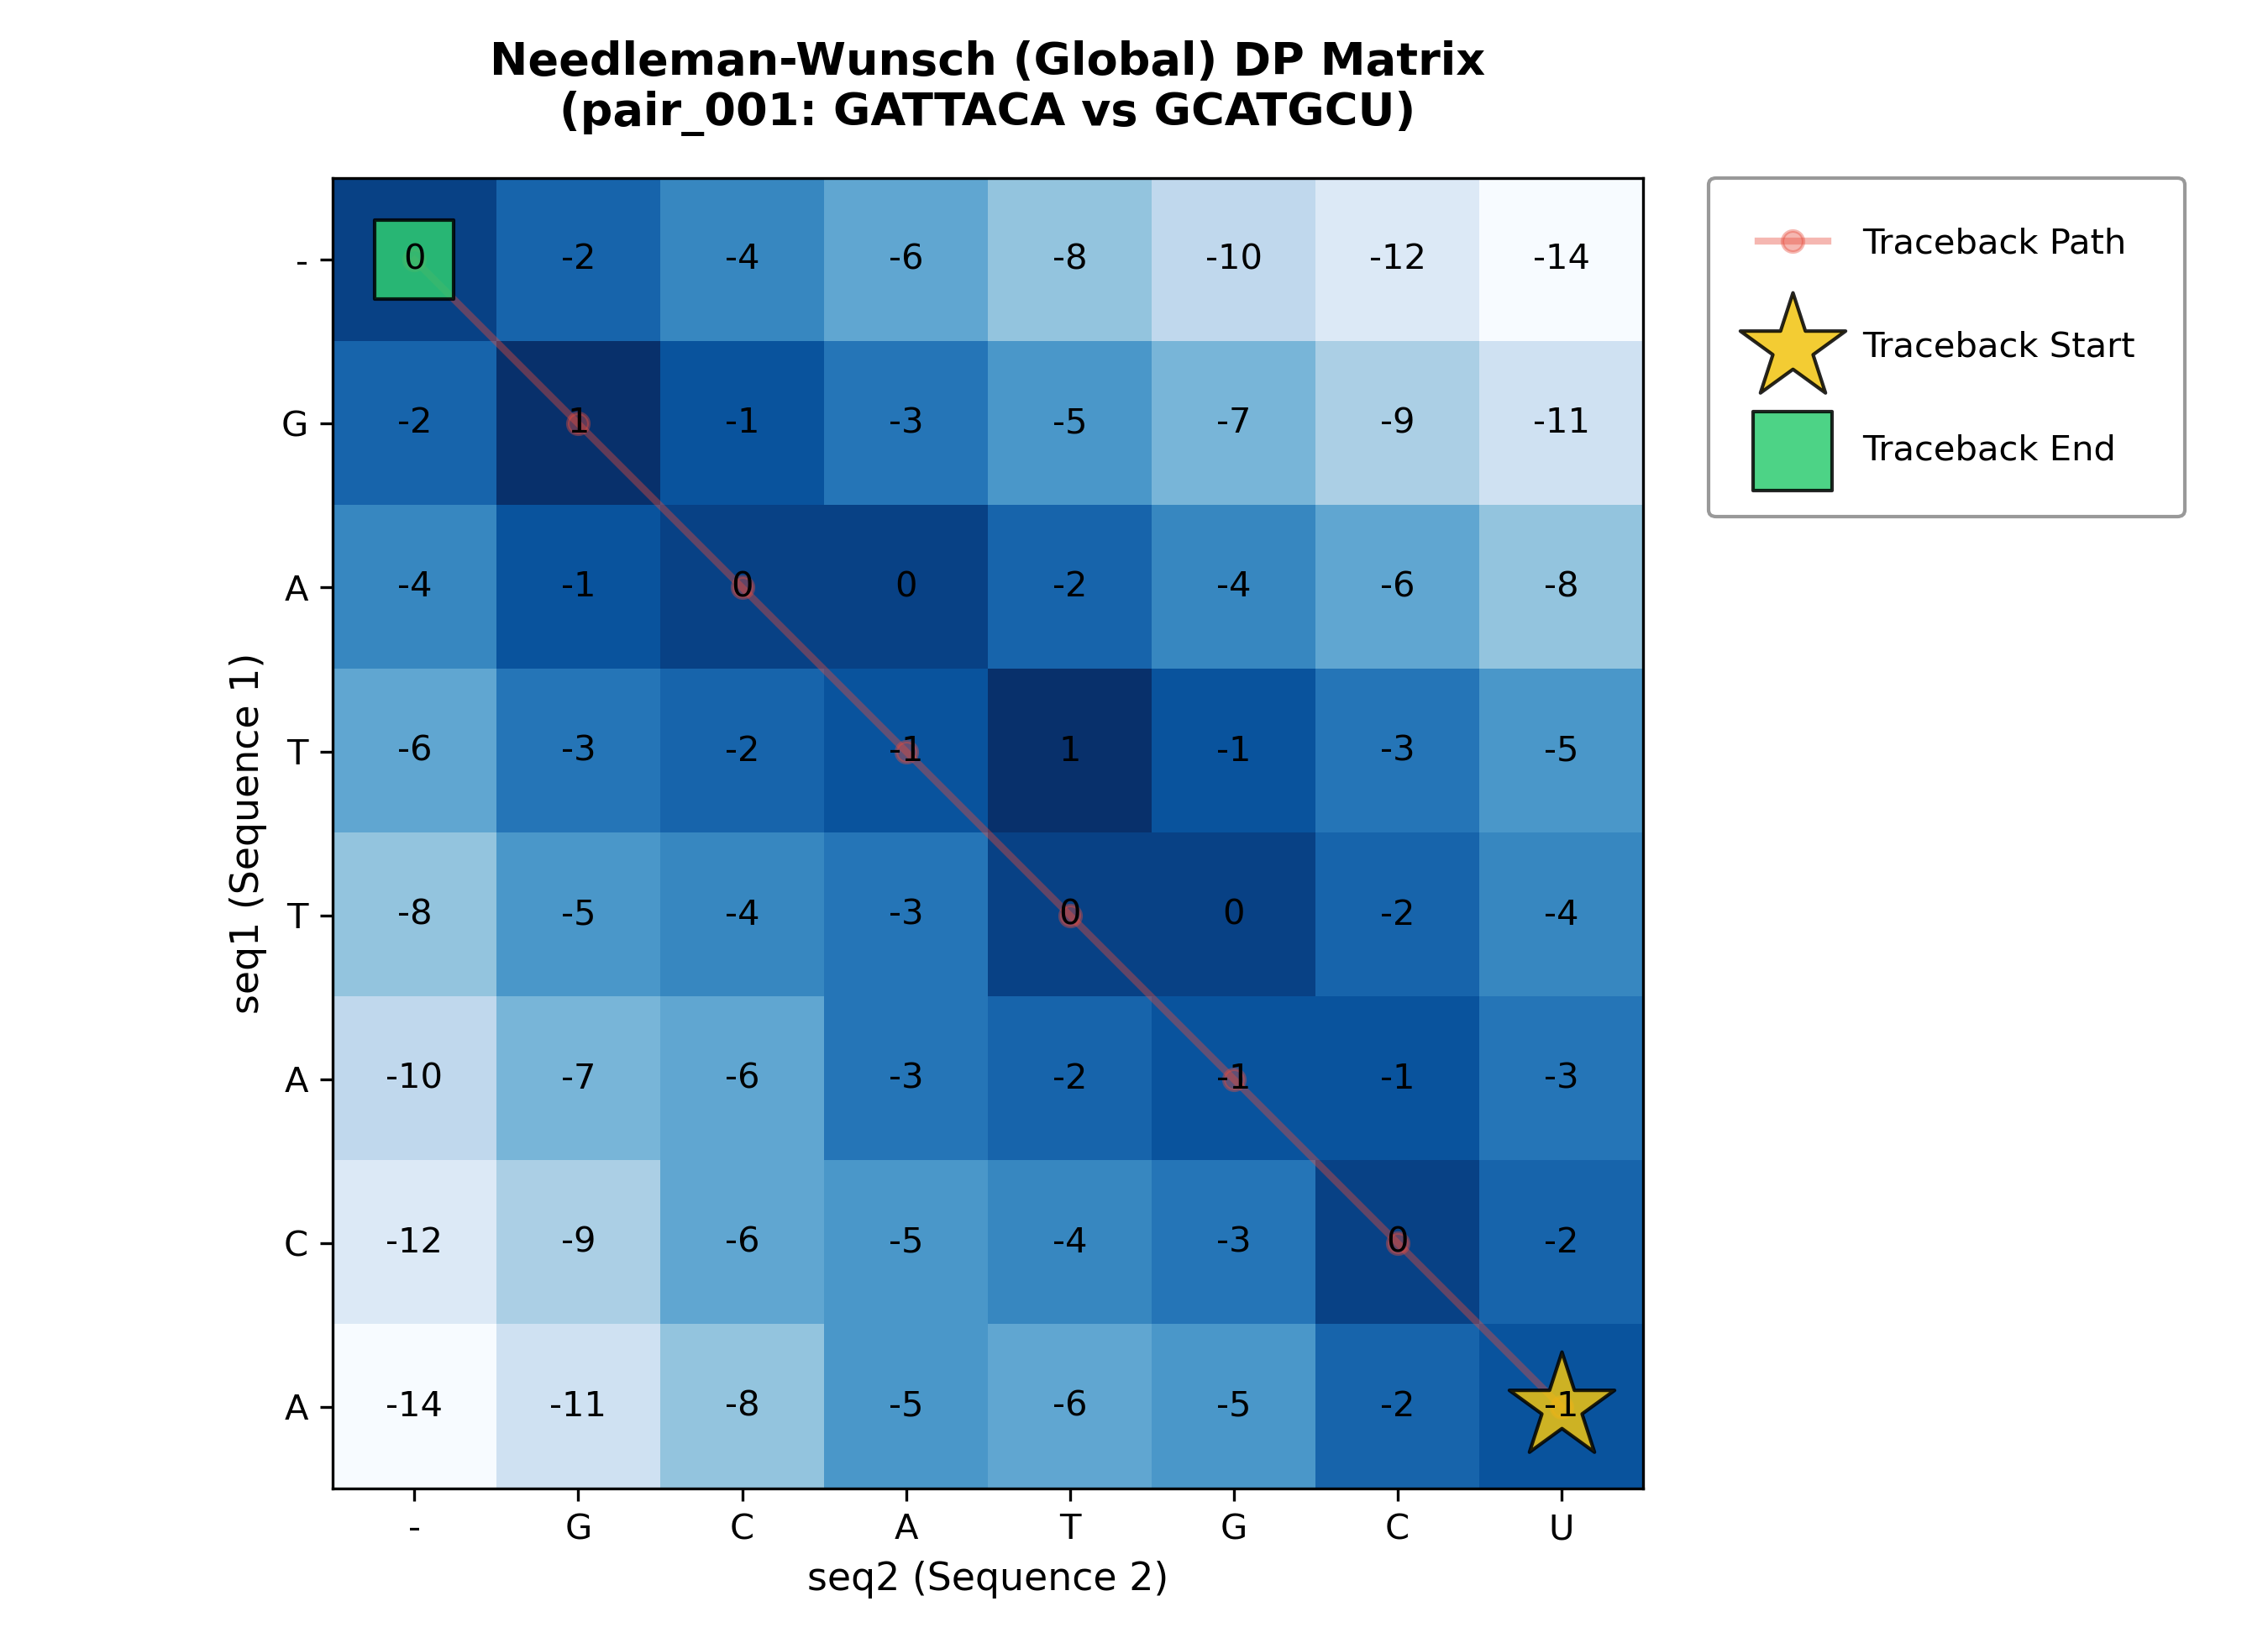


--- 局部比对（SW）带路径图预览 ---


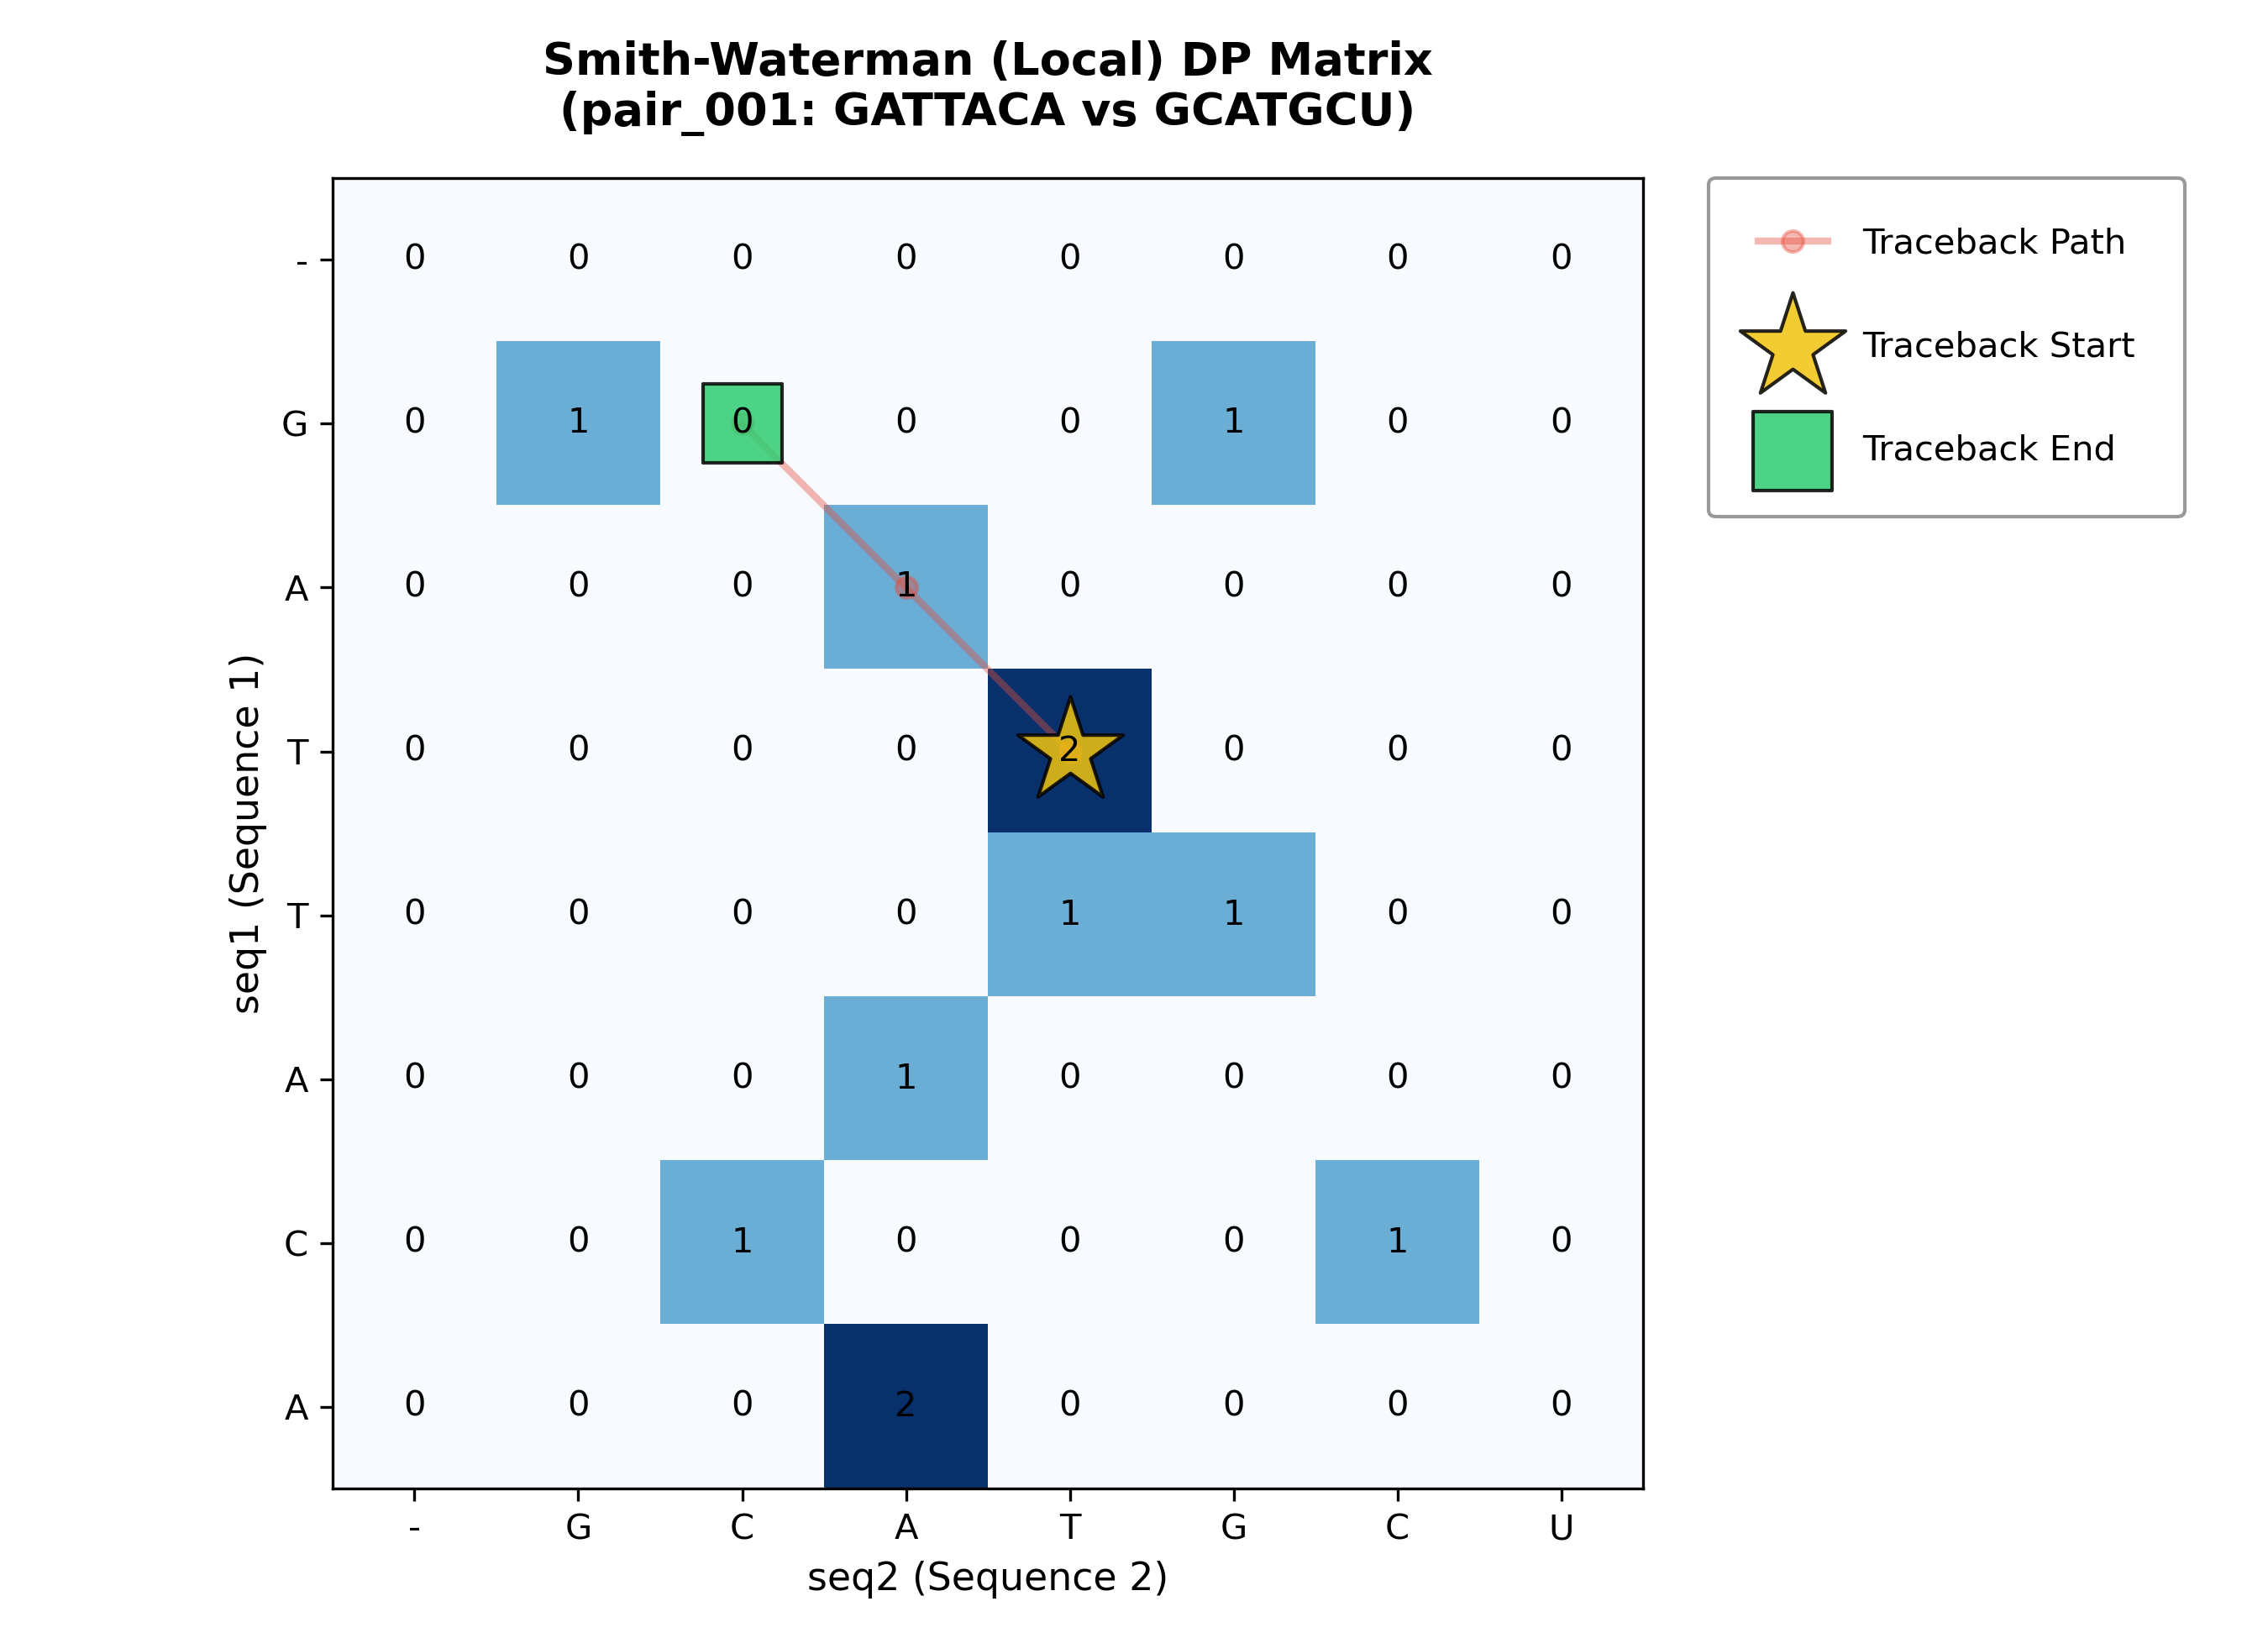

In [73]:
from IPython.display import Image, display
import matplotlib.pyplot as plt

# 1. 定义相对保存路径
global_fig_path = f"submissions/{YOUR_NAME}/week2/figures/week2_global_dp_matrix.png"
local_fig_path = f"submissions/{YOUR_NAME}/week2/figures/week2_local_dp_matrix.png"

# =====================================================================
#  plot_score_matrix 函数
# =====================================================================
def plot_score_matrix_v2(score_matrix, seq1, seq2, output_path, title, path_coords=None):
    fig, ax = plt.subplots(figsize=(9.0, 6.5))
    
    # 绘制背景
    ax.imshow(score_matrix, cmap="Blues")
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel("seq2 (Sequence 2)", fontsize=11)
    ax.set_ylabel("seq1 (Sequence 1)", fontsize=11)
    
    # 设置刻度
    ax.set_xticks(range(len(seq2) + 1))
    ax.set_yticks(range(len(seq1) + 1))
    ax.set_xticklabels(["-"] + list(seq2))
    ax.set_yticklabels(["-"] + list(seq1))
    
    # 绘制 Traceback 路径
    if path_coords is not None:

        j_coords = [coord[1] for coord in path_coords]  
        i_coords = [coord[0] for coord in path_coords]  
        
        ax.plot(j_coords, i_coords, color='#e74c3c', linewidth=2.0, 
                linestyle='-', marker='o', markersize=6, alpha=0.4, zorder=2, label="Traceback Path")
        
        ax.scatter(j_coords[0], i_coords[0], color='#f1c40f', s=1000, marker='*', 
                   edgecolors='black', linewidths=1.0, alpha=0.85, zorder=3, label="Traceback Start")
        
        ax.scatter(j_coords[-1], i_coords[-1], color='#2ecc71', s=500, marker='s', 
                   edgecolors='black', linewidths=1.0, alpha=0.85, zorder=3, label="Traceback End")
        
        # 显示图例
        ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left', borderaxespad=0., 
          frameon=True, facecolor='white', edgecolor='gray', labelspacing=2.0, handletextpad=1.0, borderpad=1.4, fontsize=10)          
        
    # 3. 填充数字得分
    for i in range(score_matrix.shape[0]):
        for j in range(score_matrix.shape[1]):
            is_on_path = False
            if path_coords is not None and (i, j) in path_coords:
                is_on_path = True
                
            font_color = "black"
            font_weight = "normal"
            
            ax.text(j, i, str(score_matrix[i, j]), ha="center", va="center", 
                    color=font_color, fontweight=font_weight, zorder=4)
                
    fig.tight_layout()
    fig.savefig(output_path, dpi=300)
    plt.close(fig)

# =====================================================================
# 运行算法，捕获路径并画图
# =====================================================================
nw_mat, _, _, _, nw_path = needleman_wunsch("GATTACA", "GCATGCU", match=1, mismatch=-1, gap=-2)
sw_mat, _, _, _, _, sw_path = smith_waterman("GATTACA", "GCATGCU", match=1, mismatch=-1, gap=-2)

# 调用画图函数
plot_score_matrix_v2(nw_mat, "GATTACA", "GCATGCU", global_fig_path, 
                     "Needleman-Wunsch (Global) DP Matrix\n(pair_001: GATTACA vs GCATGCU)", 
                     path_coords=nw_path)

plot_score_matrix_v2(sw_mat, "GATTACA", "GCATGCU", local_fig_path, 
                     "Smith-Waterman (Local) DP Matrix\n(pair_001: GATTACA vs GCATGCU)", 
                     path_coords=sw_path)

print("两张热图已成功导出")

# 预览
print("\n--- 全局比对（NW）带路径图预览 ---")
display(Image(filename=global_fig_path))
print("\n--- 局部比对（SW）带路径图预览 ---")
display(Image(filename=local_fig_path))

In [74]:
# 搬运骨架里的 Biopython 验证验证函数
def biopython_score_example(seq1: str, seq2: str, mode="global"):
    from Bio import Align
    aligner = Align.PairwiseAligner()
    aligner.mode = mode
    aligner.match_score = 1
    aligner.mismatch_score = -1
    
    try:
        aligner.gap_score = -2
    except Exception:

        aligner.open_gap_score = -2
        aligner.extend_gap_score = -2
        
    alignments = aligner.align(seq1, seq2)
    return alignments.score

# 选择 pair_001 和 pair_003 两组序列，分别进行 NW 和 SW 交叉比对验证
test_pairs = [
    {"pair_id": "pair_001", "seq1": "GATTACA", "seq2": "GCATGCU"},
    {"pair_id": "pair_003", "seq1": "TTACGTAA", "seq2": "GGACGTCC"}
]

print("="*60)
print(f"{'序列对':^10} | {'比对模式':^6} | {'手写得分':^6} | {'Biopython得分':^10} | {'验证状态':^6}")
print("="*60)

for p in test_pairs:
    s1, s2 = p["seq1"], p["seq2"]
    
    # 验证 NW 全局比对，默认参数
    _, al1, al2, my_nw_score, _ = needleman_wunsch(s1, s2, match=1, mismatch=-1, gap=-2)
    bio_nw_score = biopython_score_example(s1, s2, mode="global")
    status_nw = "PASS ✅" if my_nw_score == bio_nw_score else "FAIL ❌"
    print(f"{p['pair_id']:^12} | {'NW (Global)':^9} | {my_nw_score:^8} | {bio_nw_score:^12.1f} | {status_nw:^6}")
    
    # 验证 SW 局部比对，默认参数
    _, al1, al2, my_sw_score, _, _ = smith_waterman(s1, s2, match=1, mismatch=-1, gap=-2)
    bio_sw_score = biopython_score_example(s1, s2, mode="local")
    status_sw = "PASS ✅" if my_sw_score == bio_sw_score else "FAIL ❌"
    print(f"{p['pair_id']:^12} | {'SW (Local)':^9} | {my_sw_score:^8} | {bio_sw_score:^12.1f} | {status_sw:^6}")
    
print("="*60)

   序列对     |  比对模式  |  手写得分  | Biopython得分 |  验证状态 
  pair_001   | NW (Global) |    -1    |     -1.0     | PASS ✅
  pair_001   | SW (Local) |    2     |     2.0      | PASS ✅
  pair_003   | NW (Global) |    0     |     0.0      | PASS ✅
  pair_003   | SW (Local) |    4     |     4.0      | PASS ✅
